# Reporte de perfilado - NovaMarket

## 1. Carga de bibliotecas y dataset

In [11]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "NovaMarket_datos_crudos.csv"

df = pd.read_csv(DATA_PATH)
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
display(df.head())

Filas: 620
Columnas: 14


,id_pedido,id_cliente,fecha_compra,canal,ciudad,codigo_postal,categoria_producto,producto,precio,unidades,edad_cliente,correo,nivel_satisfaccion,fecha_actualizacion_stock
0,P00383,C0276,2026-01-03,App,Bucaramanga,68001,Belleza,Camiseta,"-1,742,611.00",4,-19,c0276gmail.com,alto,2026-07-01
1,P00403,C0167,6/12/2026,Web,Cali,76001,Deportes,Cafetera,"1,828,583.00",2,23,c0167@hotmail.com,MEDIO,2026-07-01
2,P00403,C0167,6/12/2026,Web,Cali,76001,Deportes,Cafetera,"1,828,583.00",2,23,c0167@hotmail.com,MEDIO,2026-07-01
3,P00450,C0128,07/09/2026,App,bucaramanga,68001,electronica,Set bloques,"787,178.00",6,69,c0128@hotmail.com,MEDIO,2026-07-15
4,P00449,C0304,2025-07-19,Tienda,Bogotá,8001,Belleza,Audífonos BT,"357,231.00",5,67,c0304@novamarket.co,Bajo,2026-05-20


## 2. Estructura, tipos de dato y faltantes

In [12]:
resumen_columnas = pd.DataFrame({
    "variable": df.columns,
    "tipo_dato": df.dtypes.astype(str).values,
    "no_nulos": df.notna().sum().values,
    "faltantes": df.isna().sum().values,
    "porcentaje_faltantes": (df.isna().mean() * 100).round(2).values,
    "cardinalidad": df.nunique(dropna=True).values,
    "porcentaje_cardinalidad": (df.nunique(dropna=True) / len(df) * 100).round(2).values,
})

display(resumen_columnas)

,variable,tipo_dato,no_nulos,faltantes,porcentaje_faltantes,cardinalidad,porcentaje_cardinalidad
0,id_pedido,str,620,0,0.00,600,96.77
1,id_cliente,str,620,0,0.00,311,50.16
2,fecha_compra,str,620,0,0.00,495,79.84
3,canal,str,620,0,0.00,3,0.48
4,ciudad,str,589,31,5.00,19,3.06
5,codigo_postal,int64,620,0,0.00,6,0.97
6,categoria_producto,str,620,0,0.00,17,2.74
7,producto,str,620,0,0.00,14,2.26
8,precio,float64,599,21,3.39,579,93.39
9,unidades,int64,620,0,0.00,12,1.94


## 3. Perfil de variables numericas

In [13]:
columnas_numericas = df.select_dtypes(include="number").columns.tolist()

perfil_numerico = df[columnas_numericas].describe().T
perfil_numerico["faltantes"] = df[columnas_numericas].isna().sum()
perfil_numerico["porcentaje_faltantes"] = (df[columnas_numericas].isna().mean() * 100).round(2)
perfil_numerico["asimetria_skew"] = df[columnas_numericas].skew()
perfil_numerico["cardinalidad"] = df[columnas_numericas].nunique(dropna=True)

display(perfil_numerico)

,count,mean,std,min,25%,50%,75%,max,faltantes,porcentaje_faltantes,asimetria_skew,cardinalidad
codigo_postal,620.00,"31,917.13","30,339.59","5,001.00","8,001.00","13,001.00","68,001.00","76,001.00",0,0.00,0.58,6
precio,599.00,"4,888,703.29","42,925,122.90","-2,448,455.00","591,402.00","1,178,666.00","1,856,670.50","773,003,787.00",21,3.39,13.90,579
unidades,620.00,188.68,"1,240.65",-3.00,2.00,3.00,5.00,"9,999.00",0,0.00,7.07,12
edad_cliente,620.00,48.01,28.67,-20.00,31.00,46.00,63.00,200.00,0,0.00,2.08,71


## 4. Perfil de variables categoricas y de texto

In [14]:
columnas_categoricas = df.select_dtypes(exclude="number").columns.tolist()

perfil_categorico = []
for col in columnas_categoricas:
    conteos = df[col].value_counts(dropna=False)
    moda = conteos.index[0]
    frecuencia_moda = conteos.iloc[0]
    perfil_categorico.append({
        "variable": col,
        "tipo_dato": str(df[col].dtype),
        "faltantes": int(df[col].isna().sum()),
        "porcentaje_faltantes": round(df[col].isna().mean() * 100, 2),
        "cardinalidad_sin_faltantes": int(df[col].nunique(dropna=True)),
        "moda_incluye_nan": moda,
        "frecuencia_moda": int(frecuencia_moda),
        "porcentaje_moda": round(frecuencia_moda / len(df) * 100, 2),
    })

perfil_categorico = pd.DataFrame(perfil_categorico)
display(perfil_categorico)

,variable,tipo_dato,faltantes,porcentaje_faltantes,cardinalidad_sin_faltantes,moda_incluye_nan,frecuencia_moda,porcentaje_moda
0,id_pedido,str,0,0.00,600,P00403,2,0.32
1,id_cliente,str,0,0.00,311,C0043,6,0.97
2,fecha_compra,str,0,0.00,495,15/11/2027,9,1.45
3,canal,str,0,0.00,3,Tienda,224,36.13
4,ciudad,str,31,5.00,19,bucaramanga,58,9.35
5,categoria_producto,str,0,0.00,17,Belleza,66,10.65
6,producto,str,0,0.00,14,Perfume,52,8.39
7,correo,str,104,16.77,429,NaN,104,16.77
8,nivel_satisfaccion,str,46,7.42,8,Alto,91,14.68
9,fecha_actualizacion_stock,str,0,0.00,8,2026-07-15,152,24.52


## 5. Frecuencias principales de variables categoricas

In [15]:
for col in columnas_categoricas:
    display(Markdown(f"### {col}"))
    tabla_frecuencias = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="frecuencia")
    )
    tabla_frecuencias["porcentaje"] = (tabla_frecuencias["frecuencia"] / len(df) * 100).round(2)
    display(tabla_frecuencias.head(12))

### id_pedido

,id_pedido,frecuencia,porcentaje
0,P00403,2,0.32
1,P00416,2,0.32
2,P00397,2,0.32
3,P00335,2,0.32
4,P00343,2,0.32
5,P00207,2,0.32
6,P00201,2,0.32
7,P00457,2,0.32
8,P00463,2,0.32
9,P00263,2,0.32


### id_cliente

,id_cliente,frecuencia,porcentaje
0,C0043,6,0.97
1,C0186,5,0.81
2,C0165,5,0.81
3,C0039,5,0.81
4,C0099,5,0.81
5,C0171,5,0.81
6,C0005,5,0.81
7,C0222,5,0.81
8,C0012,5,0.81
9,C0336,5,0.81


### fecha_compra

...

,correo,frecuencia,porcentaje
0,NaN,104,16.77
1,c0012@hotmail.com,4,0.65
2,c0336@novamarket.co,4,0.65
3,c0165@hotmail.com,3,0.48
4,c0097@hotmail.com,3,0.48
5,c0005@novamarket.co,3,0.48
6,c0145@gmail.com,3,0.48
7,c0197@hotmail.com,3,0.48
8,c0037@hotmail.com,3,0.48
9,c0038@gmail.com,3,0.48


### nivel_satisfaccion

,nivel_satisfaccion,frecuencia,porcentaje
0,Alto,91,14.68
1,ALTO,84,13.55
2,Medio,74,11.94
3,bajo,73,11.77
4,medio,70,11.29
5,alto,67,10.81
6,Bajo,62,10.00
7,MEDIO,53,8.55
8,NaN,46,7.42


### fecha_actualizacion_stock

,fecha_actualizacion_stock,frecuencia,porcentaje
0,2026-07-15,152,24.52
1,2026-05-20,134,21.61
2,2026-07-01,128,20.65
3,2026-06-10,118,19.03
4,2024-01-15,29,4.68
5,2027-03-01,21,3.39
6,2023-11-30,20,3.23
7,2024-06-01,18,2.90


## 6. Visualizacion 1: histograma de precio

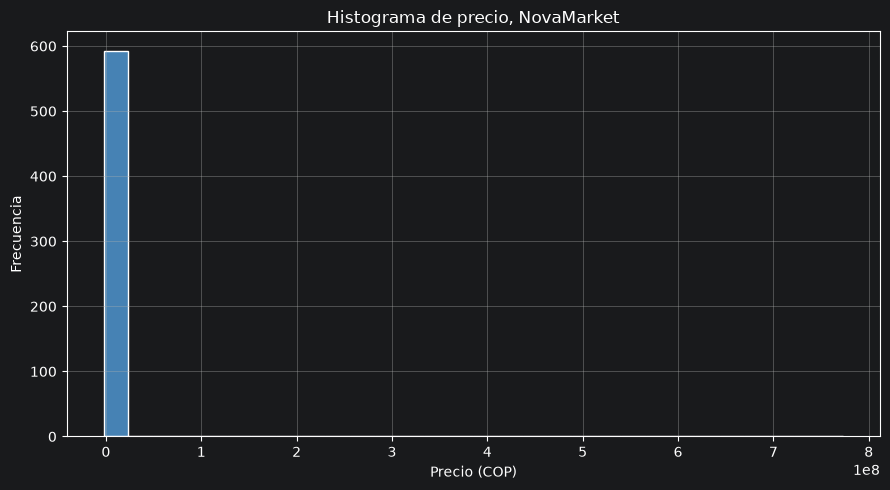

In [16]:
plt.figure(figsize=(9, 5))
df["precio"].dropna().hist(bins=30, color="steelblue", edgecolor="white")
plt.title("Histograma de precio, NovaMarket")
plt.xlabel("Precio (COP)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 7. Visualizacion 2: boxplot de precio

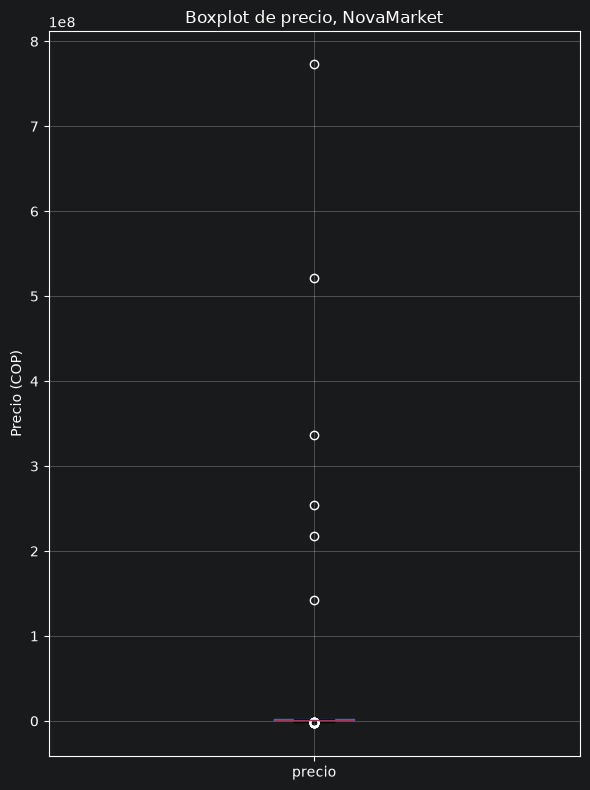

In [17]:
plt.figure(figsize=(6, 8))
df.boxplot(column="precio", vert=True)
plt.title("Boxplot de precio, NovaMarket")
plt.ylabel("Precio (COP)")
plt.tight_layout()
plt.show()

## 8. Visualizacion complementaria: boxplot de variables numericas relevantes

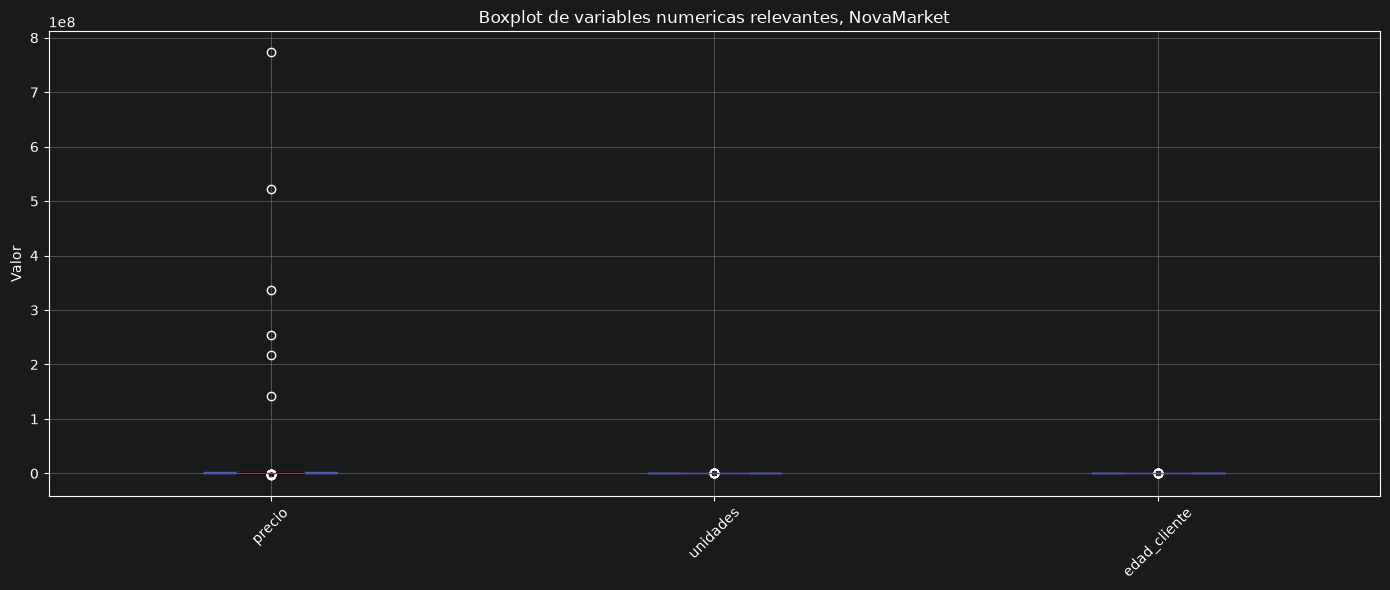

In [18]:
columnas_excluir = ["codigo_postal"]
columnas_boxplot = [col for col in columnas_numericas if col not in columnas_excluir]

df[columnas_boxplot].boxplot(figsize=(14, 6), rot=45)
plt.title("Boxplot de variables numericas relevantes, NovaMarket")
plt.ylabel("Valor")
plt.tight_layout()
plt.show()

## 9. Rutina de validaciones de calidad

In [19]:
def parse_fecha_mixta(valor):
    if pd.isna(valor):
        return pd.NaT
    texto = str(valor).strip()
    if "-" in texto:
        return pd.to_datetime(texto, format="%Y-%m-%d", errors="coerce")
    if "/" in texto:
        return pd.to_datetime(texto, format="%d/%m/%Y", errors="coerce")
    return pd.NaT


fecha_corte = pd.Timestamp("2026-07-28")
fecha_compra_parseada = df["fecha_compra"].map(parse_fecha_mixta)
fecha_stock_parseada = df["fecha_actualizacion_stock"].map(parse_fecha_mixta)

email_regex = r"^[^@\s]+@[^@\s]+\.[^@\s]+$"
correo_malformado = df["correo"].notna() & ~df["correo"].str.match(email_regex, na=False)

validaciones = pd.DataFrame([
    {
        "senal": "Filas duplicadas exactas",
        "conteo": int(df.duplicated().sum()),
        "porcentaje": round(df.duplicated().mean() * 100, 2),
    },
    {
        "senal": "id_pedido duplicado",
        "conteo": int(df["id_pedido"].duplicated().sum()),
        "porcentaje": round(df["id_pedido"].duplicated().mean() * 100, 2),
    },
    {
        "senal": "precio faltante",
        "conteo": int(df["precio"].isna().sum()),
        "porcentaje": round(df["precio"].isna().mean() * 100, 2),
    },
    {
        "senal": "precio negativo",
        "conteo": int((df["precio"] < 0).sum()),
        "porcentaje": round((df["precio"] < 0).mean() * 100, 2),
    },
    {
        "senal": "unidades <= 0",
        "conteo": int((df["unidades"] <= 0).sum()),
        "porcentaje": round((df["unidades"] <= 0).mean() * 100, 2),
    },
    {
        "senal": "edad_cliente < 0",
        "conteo": int((df["edad_cliente"] < 0).sum()),
        "porcentaje": round((df["edad_cliente"] < 0).mean() * 100, 2),
    },
    {
        "senal": "edad_cliente > 100",
        "conteo": int((df["edad_cliente"] > 100).sum()),
        "porcentaje": round((df["edad_cliente"] > 100).mean() * 100, 2),
    },
    {
        "senal": "correo faltante",
        "conteo": int(df["correo"].isna().sum()),
        "porcentaje": round(df["correo"].isna().mean() * 100, 2),
    },
    {
        "senal": "correo malformado",
        "conteo": int(correo_malformado.sum()),
        "porcentaje": round(correo_malformado.mean() * 100, 2),
    },
    {
        "senal": "fecha_compra no parseable",
        "conteo": int(fecha_compra_parseada.isna().sum()),
        "porcentaje": round(fecha_compra_parseada.isna().mean() * 100, 2),
    },
    {
        "senal": "fecha_compra futura frente a 2026-07-28",
        "conteo": int((fecha_compra_parseada > fecha_corte).sum()),
        "porcentaje": round((fecha_compra_parseada > fecha_corte).mean() * 100, 2),
    },
    {
        "senal": "fecha_actualizacion_stock futura frente a 2026-07-28",
        "conteo": int((fecha_stock_parseada > fecha_corte).sum()),
        "porcentaje": round((fecha_stock_parseada > fecha_corte).mean() * 100, 2),
    },
])

display(validaciones)

,senal,conteo,porcentaje
0,Filas duplicadas exactas,20,3.23
1,id_pedido duplicado,20,3.23
2,precio faltante,21,3.39
3,precio negativo,19,3.06
4,unidades <= 0,31,5.00
5,edad_cliente < 0,15,2.42
6,edad_cliente > 100,17,2.74
7,correo faltante,104,16.77
8,correo malformado,51,8.23
9,fecha_compra no parseable,22,3.55


## 10. Señales de alerta detectadas

- Hay 20 filas duplicadas exactas y 20 valores repetidos en id_pedido.
- La columna precio tiene 21 faltantes (3.39%) y 19 valores negativos.
- El precio maximo es 773,003,787 COP, muy superior al percentil 75 (1,856,670 COP); requiere revision como posible outlier o error de digitacion.
- La columna unidades tiene 31 registros con unidades <= 0 y un maximo de 9,999, valor extremo para una compra minorista.
- La columna edad_cliente tiene 15 edades negativas y 17 edades mayores a 100; el maximo observado es 200.
- correo tiene 104 faltantes (16.77%) y 51 correos con formato invalido.
- fecha_compra tiene 22 fechas no parseables y 132 fechas futuras frente a 2026-07-28.
- fecha_actualizacion_stock tiene 21 fechas futuras frente a 2026-07-28.
- ciudad muestra 19 categorias originales, pero baja a 10 al normalizar mayusculas/minusculas.
- categoria_producto muestra 17 categorias originales, pero baja a 9 al normalizar.
- nivel_satisfaccion muestra 8 categorias originales, pero baja a 3 al normalizar.